In [ ]:
%pip install pandas numpy matplotlib

=== RANDOM ===
[(270000.0, 10.300000000000006, 105.30094728079277, 410), (276000.0, 9.800000000000004, 104.28141042278897, 464), (287000.0, 9.500000000000002, 106.19271451619947, 191), (241000.0, 9.200000000000001, 105.6877344597118, 207), (289000.0, 8.800000000000004, 107.27010656491538, 473), (280000.0, 8.600000000000001, 112.63070369567512, 242), (279000.0, 8.4, 109.41417418103755, 253), (288000.0, 8.299999999999999, 105.26295647901294, 194), (267000.0, 8.200000000000001, 100.40590734480058, 263), (261000.0, 8.200000000000001, 95.39541906361562, 407), (158000.0, 8.100000000000001, 97.48696874217607, 64), (299000.0, 8.100000000000001, 95.02704744924984, 439), (286000.0, 8.000000000000002, 104.09098696738076, 431), (258000.0, 7.900000000000002, 102.70424335998963, 318), (158000.0, 7.900000000000002, 103.69625578351273, 355), (150000.0, 7.8, 100.26866820794628, 110), (288000.0, 7.700000000000002, 105.67992712288941, 326), (299000.0, 7.7, 103.76115674528111, 303), (264000.0, 7.699999999

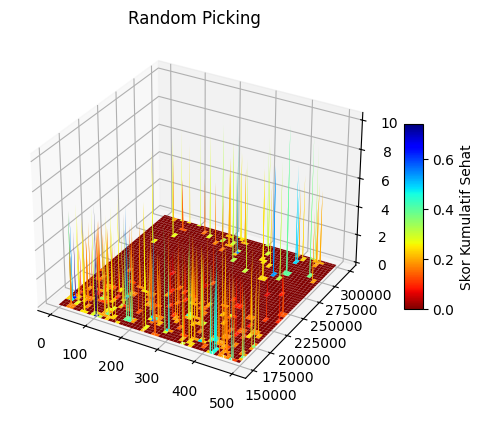

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

NPM = 90        
np.random.seed(NPM)

makan =  pd.read_excel("https://github.com/adriann03/dataset_mahasiswa_matdis_a/raw/refs/heads/main/dataset_makanan_matdis.xlsx", engine='openpyxl')
# mohon ditambahkan (lagi) agar lebih beragam

budget= 1e6 #rupiah

wkenyang_base= 1.1
wrasa_base= 0.7
wsehat_base= 0.9 # simpangan lebih besar
wbosan_base= 0.5

skor_kumulatif= 0.0
SAMPLE_NUM= 500

sampleid= np.arange(0, 500)
# skor perorangan
skor= np.zeros(SAMPLE_NUM, dtype=np.double)
sisa= np.zeros(SAMPLE_NUM, dtype=np.double)
sehat= np.zeros(SAMPLE_NUM, dtype=np.double)
pilihankum= np.zeros(SAMPLE_NUM, dtype=np.double)

SISA_MININUM= 150e3
SISA_MAKSIMUM= 300e3
bin_sisa= np.arange(SISA_MININUM, SISA_MAKSIMUM, 1000)
resp_sehat= np.zeros((SAMPLE_NUM, len(bin_sisa)), dtype=np.double)
resp_pilih= np.zeros((SAMPLE_NUM, 62), dtype=np.double)
for n in range(0, SAMPLE_NUM):
    budget = 1e6
    skor_kumulatif = 0
    skor_sehat = 0

    for i in range(0, 31): # hari
        # makan pertama, pilih secara acak
        pilihan= np.random.randint(0, len(makan))
        # update weight factor
        w_kenyang= np.random.normal(loc=wkenyang_base, scale=0.2)
        w_rasa= np.random.normal(loc=wrasa_base, scale=0.2)
        w_sehat= np.random.normal(loc=wsehat_base, scale=0.4)
        w_bosan= np.random.normal(loc=wbosan_base, scale=0.2)
        skor_kumulatif= skor_kumulatif + \
            w_kenyang * makan['kenyang'][pilihan]\
            + w_rasa * makan['rasa'][pilihan] \
            + w_sehat * makan['sehat'][pilihan] \
            - w_bosan * makan['bosan'][pilihan]
        skor_sehat += makan['sehat'][pilihan] - 0.5
        budget = budget - makan['harga'][pilihan]
        #print(f"hari {i} pagi: {makan['makanan'][pilihan]}") 
        resp_pilih[n][2*i]= pilihan
        
        # makan keduas
        pilihan= np.random.randint(0, len(makan))
        # update weight factor
        w_kenyang= np.random.normal(loc=wkenyang_base, scale=0.2)
        w_rasa= np.random.normal(loc=wrasa_base, scale=0.2)
        w_sehat= np.random.normal(loc=wsehat_base+0.2, scale=0.4)
        w_bosan= np.random.normal(loc=wbosan_base*2, scale=0.2)
        skor_kumulatif= skor_kumulatif\
            + w_kenyang * makan['kenyang'][pilihan]\
            + w_rasa * makan['rasa'][pilihan] \
            + w_sehat * makan['sehat'][pilihan] \
            - w_bosan * makan['bosan'][pilihan]
        skor_sehat += max(makan['sehat'][pilihan] - 0.5, 0)
        budget = budget - makan['harga'][pilihan]
        #print(f"hari {i} malam: {makan['makanan'][pilihan]}")    
        resp_pilih[n][2*i+1]= pilihan
    
    # print(f"skor: {skor_kumulatif}, sisa uang: {budget}")    
    sisa[n]= budget
    skor[n]= skor_kumulatif
    sehat[n]= skor_sehat
    # print(f"{n} skor sehat:{skor_sehat}")
    
    resp_sehat[n][ int((budget-SISA_MININUM)/1000)]= skor_sehat

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.set_title("Random Picking")
Y, X = np.meshgrid(bin_sisa, sampleid)
# Colorize the surface using a colormap
surf = ax.plot_surface(X, Y, resp_sehat, 
                       cmap='jet_r',   # try 'plasma', 'coolwarm', etc.
                       edgecolor='none')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label="Skor Kumulatif Sehat")

# plot yang ini barangkali butuh dipercantik

# TUGAS
# (1) cari pola makan mana saja yang menghasilkan nilai kumulatif kesehatan (resp_sehat) positif 
# (2) cari titik-titik dengan sisa uang bulanan positif dari (1)
# (3) cari titik dengan skor skumulatif terbesar (skor) di mana nilai kumulatif kesehatannya positif
# (4) tampikan jadwal makanan sesuai pilihan (resp_pilih)

values = []
for i in range(SAMPLE_NUM):
    max_value = resp_sehat[i][0]
    j_max = 0
    for j in range(len(bin_sisa)):
        if resp_sehat[i][j] > max_value:
            max_value = resp_sehat[i][j]
            j_max = j
        if j == len(bin_sisa) - 1:
            values.append((bin_sisa[j_max].item(), max_value.item(), skor[i].item(), i))
descending_sorted_values = sorted(values, key=lambda element: element[1], reverse=True)
print(descending_sorted_values)
print(resp_pilih[descending_sorted_values[0][3]])
for i in range(len(resp_pilih[descending_sorted_values[0][3]])):
    day = ["pagi", "malam"]
    print(f"Hari ke-{i//2 + 1} {day[i%2]}: {makan['makanan'][int(resp_pilih[descending_sorted_values[0][3]][i])]}")

Skor relatif lebih besar sebab tidak ada hukuman memilih makanan yang sama dengan sebelumnya

=== GOURMARYLLIS MECHANIC ===
[(233000.0, 8.590664613164613, 4.574178802118637, 312), (272000.0, 8.149285714285718, 3.6414289117163454, 402), (235000.0, 7.9771428571428595, 2.646447904658162, 491), (260000.0, 7.9564847489112225, 2.1864808186216247, 397), (209000.0, 7.932023809523807, 3.785186767701872, 76), (223000.0, 7.90093406593407, 2.645807531265364, 267), (282000.0, 7.671637806637806, 2.8161623219356624, 52), (262000.0, 7.589999999999999, 2.8434371967674354, 430), (241000.0, 7.382301587301587, 2.6807049892788695, 116), (233000.0, 7.32527777777778, 2.251556638751432, 224), (263000.0, 7.243134920634918, 5.852152738937716, 200), (244000.0, 7.220447330447331, 2.655979133388552, 64), (265000.0, 7.201666666666668, 6.8097559190311605, 289), (238000.0, 7.108885003885005, 1.6645210103952308, 392), (255000.0, 7.105770593355731, 5.193863970805404, 77), (237000.0, 7.105000000000002, 2.653978513257038, 328), (218000.0, 7.1033874458874475, 1.825315208526754, 98), (280000.0, 7.083571428571428, 6

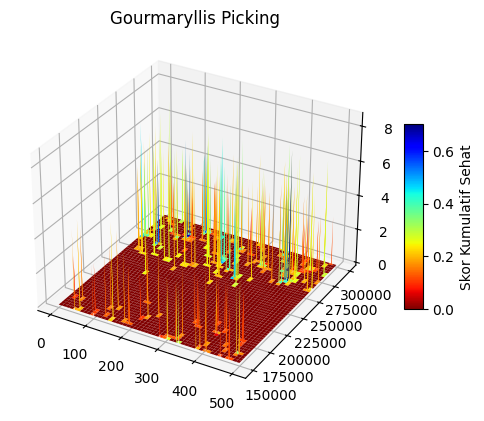

In [ ]:
budget= 1e6 #rupiah

wkenyang_base= 1.1
wrasa_base= 0.7
wsehat_base= 0.9 # simpangan lebih besar
wbosan_base= 0.5

skor_kumulatif= 0.0
SAMPLE_NUM= 500

sampleid= np.arange(0, 500)
# skor perorangan
skor= np.zeros(SAMPLE_NUM, dtype=np.double)
sisa= np.zeros(SAMPLE_NUM, dtype=np.double)
sehat= np.zeros(SAMPLE_NUM, dtype=np.double)
pilihankum= np.zeros(SAMPLE_NUM, dtype=np.double)

SISA_MININUM= 150e3
SISA_MAKSIMUM= 300e3
bin_sisa= np.arange(SISA_MININUM, SISA_MAKSIMUM, 1000)
resp_sehat= np.zeros((SAMPLE_NUM, len(bin_sisa)), dtype=np.double)
resp_pilih= np.zeros((SAMPLE_NUM, 62), dtype=np.double)

weights = makan['sehat'].values
weights = weights / weights.sum()  # Normalize to sum to 1
max_chosen = 8
for n in range(0, SAMPLE_NUM):
    budget = 1e6
    skor_kumulatif = 0
    skor_sehat = 0
    chosen_menu = []
    same_food_penalty = 0
    different_streak_bonus = 0
    for i in range(0, 31): # hari
        # makan pertama, pilih secara acak
        pilihan= np.random.choice(len(makan), p=weights)
        
        if pilihan in chosen_menu:
            different_streak_bonus = 0
            same_food_penalty += 1
        else:
            same_food_penalty = 0
            different_streak_bonus = min(different_streak_bonus + 1, 8)
        chosen_menu.append(pilihan)
        # update weight factor
        w_kenyang= np.random.normal(loc=wkenyang_base, scale=0.2)
        w_rasa= np.random.normal(loc=wrasa_base, scale=0.2)
        w_sehat= np.random.normal(loc=wsehat_base, scale=0.4)
        w_bosan= np.random.normal(loc=wbosan_base, scale=0.2)
        skor_kumulatif= (skor_kumulatif + \
            w_kenyang * makan['kenyang'][pilihan]\
            + w_rasa * makan['rasa'][pilihan] \
            + w_sehat * makan['sehat'][pilihan] \
            - w_bosan * makan['bosan'][pilihan]) * (1 + different_streak_bonus * 0.1) / (1 + same_food_penalty)
        skor_sehat += max(makan['sehat'][pilihan] - 0.5, 0) * (1 + different_streak_bonus * 0.1) / (1 + same_food_penalty)
        budget = budget - makan['harga'][pilihan]
        #print(f"hari {i} pagi: {makan['makanan'][pilihan]}") 
        resp_pilih[n][2*i]= pilihan
        
        # makan keduas
        pilihan= np.random.randint(0, len(makan))
        # update weight factor
        w_kenyang= np.random.normal(loc=wkenyang_base, scale=0.2)
        w_rasa= np.random.normal(loc=wrasa_base, scale=0.2)
        w_sehat= np.random.normal(loc=wsehat_base+0.2, scale=0.4)
        w_bosan= np.random.normal(loc=wbosan_base*2, scale=0.2)
        skor_kumulatif= skor_kumulatif\
            + w_kenyang * makan['kenyang'][pilihan]\
            + w_rasa * makan['rasa'][pilihan] \
            + w_sehat * makan['sehat'][pilihan] \
            - w_bosan * makan['bosan'][pilihan]
        skor_sehat += makan['sehat'][pilihan] - 0.5
        budget = budget - makan['harga'][pilihan]
        #print(f"hari {i} malam: {makan['makanan'][pilihan]}")    
        resp_pilih[n][2*i+1]= pilihan
    
    # print(f"skor: {skor_kumulatif}, sisa uang: {budget}")    
    sisa[n]= budget
    skor[n]= skor_kumulatif
    sehat[n]= skor_sehat
    # print(f"{n} skor sehat:{skor_sehat}")
    
    resp_sehat[n][ int((budget-SISA_MININUM)/1000)]= skor_sehat

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.set_title("Gourmaryllis Picking")
Y, X = np.meshgrid(bin_sisa, sampleid)
# Colorize the surface using a colormap
surf = ax.plot_surface(X, Y, resp_sehat, 
                       cmap='jet_r',   # try 'plasma', 'coolwarm', etc.
                       edgecolor='none')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label="Skor Kumulatif Sehat")

# plot yang ini barangkali butuh dipercantik

# TUGAS
# (1) cari pola makan mana saja yang menghasilkan nilai kumulatif kesehatan (resp_sehat) positif 
# (2) cari titik-titik dengan sisa uang bulanan positif dari (1)
# (3) cari titik dengan skor skumulatif terbesar (skor) di mana nilai kumulatif kesehatannya positif
# (4) tampikan jadwal makanan sesuai pilihan (resp_pilih)

values = []
for i in range(SAMPLE_NUM):
    max_value = resp_sehat[i][j]
    j_max = 0
    for j in range(len(bin_sisa)):
        if resp_sehat[i][j] > max_value:
            max_value = resp_sehat[i][j]
            j_max = j
        if j == len(bin_sisa) - 1:
            values.append((bin_sisa[j_max].item(), max_value.item(), skor[i].item(), i))
descending_sorted_values = sorted(values, key=lambda element: element[1], reverse=True)
print(descending_sorted_values)
print(resp_pilih[descending_sorted_values[0][3]])
for i in range(len(resp_pilih[descending_sorted_values[0][3]])):
    day = ["pagi", "malam"]
    print(f"Hari ke-{i//2 + 1} {day[i%2]}: {makan['makanan'][int(resp_pilih[descending_sorted_values[0][3]][i])]}")

Skor relatif lebih kecil sebab terdapat hukuman memilih makanan yang sama dengan sebelumnya. Semakin lama tidak ganti menu, semakin tidak efisien perolehan skornya (bisa mendekati 0)

Mungkin saya lebih suka mekanisme gourmaryllis picking (botania) karena saya percaya bahwa makan yang itu-itu terus bisa menjadi cepat bosan dan tidak seimbang yang berakibat menjadi tidak sehat meskipun makanan itu memang "sehat". Tanaman pertanian saja perlu rotasi, masa menu makanan tidak?